## Overspeeding Trend Analysis

I will now process the data to identify overspeeding violations and then visualize their trends over time (date-wise and time-wise).

In [ ]:
print(df.columns)

Index(['license type', 'place of issue', 'vehicle type', 'sub vehicle',
       'model', 'name', 'address', 'cnic', 'gender', 'mobile number', 'driver',
       'Area', 'Error Cooe', 'Violation details', '     Amount',
       'collection number', 'speed limit', 'speed measured', 'date', ' time',
       'CNIC Validation Status', 'Mobile Validation Status', 'datetime'],
      dtype='object')


### Date-wise Overspeeding Trends

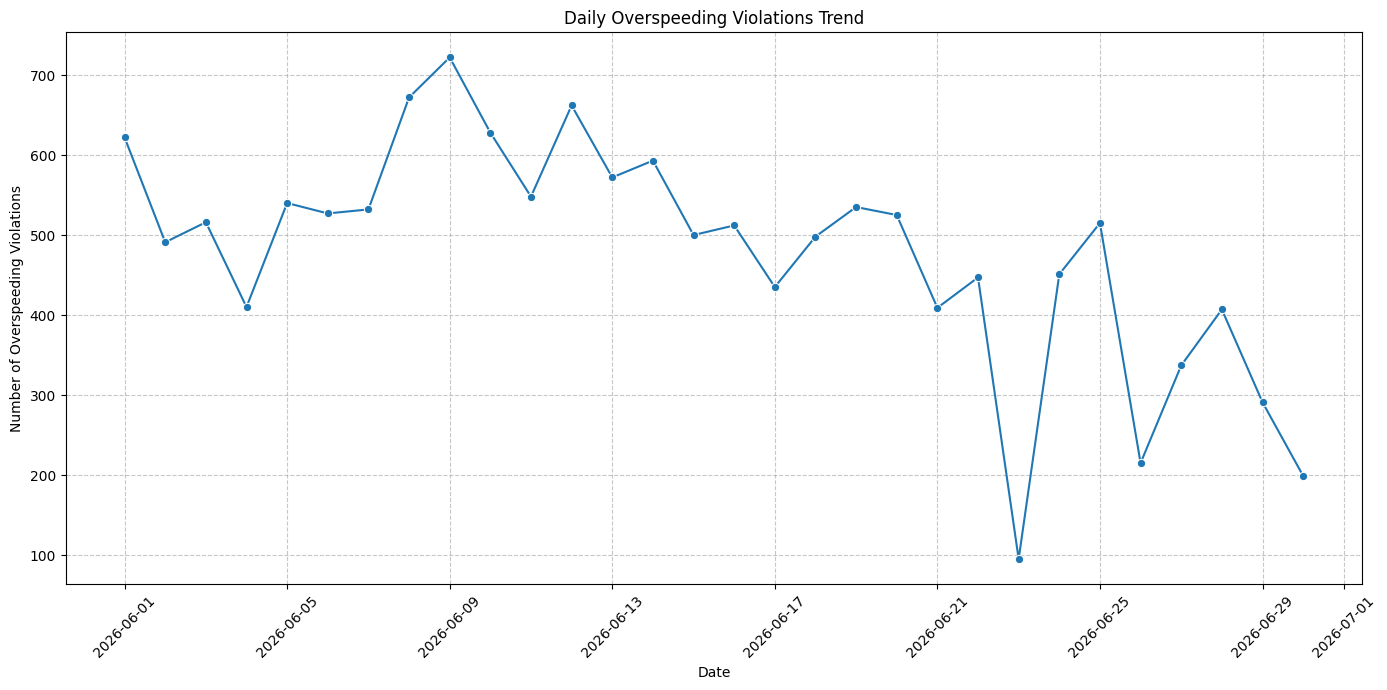

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Extract date for daily trend
df_speed_analysis['date_only'] = df_speed_analysis['datetime'].dt.date

# Calculate daily overspeeding counts
daily_overspeeding = df_speed_analysis[df_speed_analysis['is_overspeeding']].groupby('date_only').size().reset_index(name='overspeeding_count')

plt.figure(figsize=(14, 7))
sns.lineplot(x='date_only', y='overspeeding_count', data=daily_overspeeding, marker='o')
plt.title('Daily Overspeeding Violations Trend')
plt.xlabel('Date')
plt.ylabel('Number of Overspeeding Violations')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Machine Learning Model for Overspeeding Trend Prediction


--- Model Evaluation ---
Mean Absolute Error (MAE): 101.10
Mean Squared Error (MSE): 13451.88
Root Mean Squared Error (RMSE): 115.98
R-squared (R2): -0.17


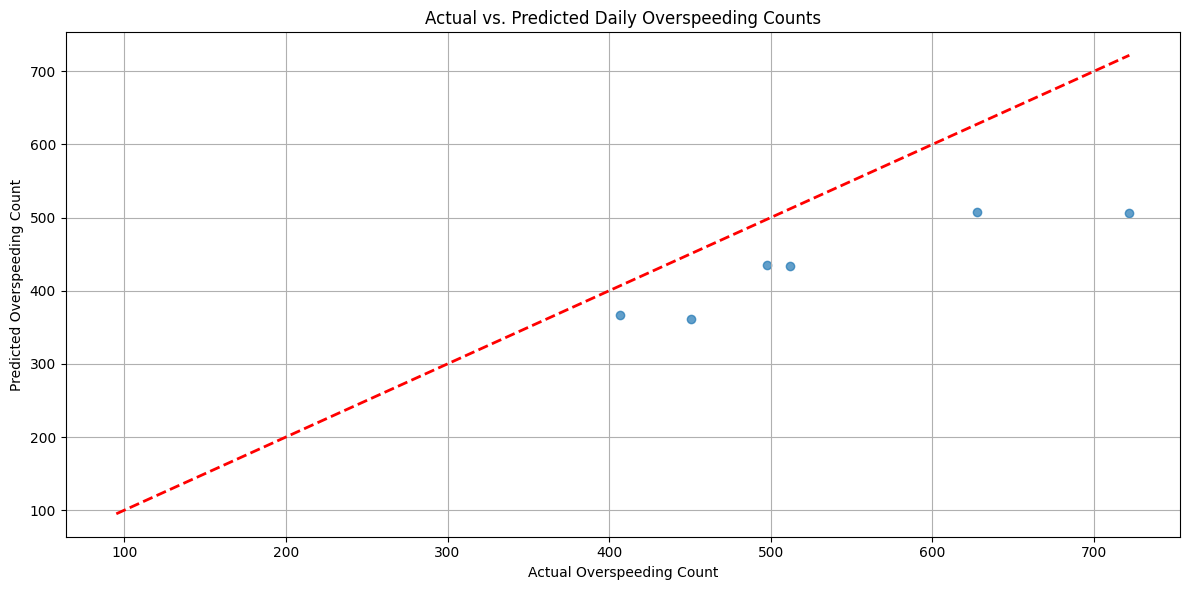


Machine Learning model training and evaluation complete.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure daily_overspeeding is a DataFrame and datetime column is processed
if 'date_only' in daily_overspeeding.columns:
    daily_overspeeding['date_only'] = pd.to_datetime(daily_overspeeding['date_only'])

# Feature Engineering
# Extract features from date_only column
df_ml = daily_overspeeding.copy()
df_ml['day_of_week'] = df_ml['date_only'].dt.dayofweek  # Monday=0, Sunday=6
df_ml['day_of_month'] = df_ml['date_only'].dt.day
df_ml['month'] = df_ml['date_only'].dt.month

# Define features (X) and target (y)
X = df_ml[['day_of_week', 'day_of_month', 'month']]
y = df_ml['overspeeding_count']

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Visualize predictions vs actual values
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Line for perfect prediction
plt.xlabel('Actual Overspeeding Count')
plt.ylabel('Predicted Overspeeding Count')
plt.title('Actual vs. Predicted Daily Overspeeding Counts')
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nMachine Learning model training and evaluation complete.")

### Machine Learning Model for Overspeeding Trend Prediction


--- Model Evaluation ---
Mean Absolute Error (MAE): 101.10
Mean Squared Error (MSE): 13451.88
Root Mean Squared Error (RMSE): 115.98
R-squared (R2): -0.17


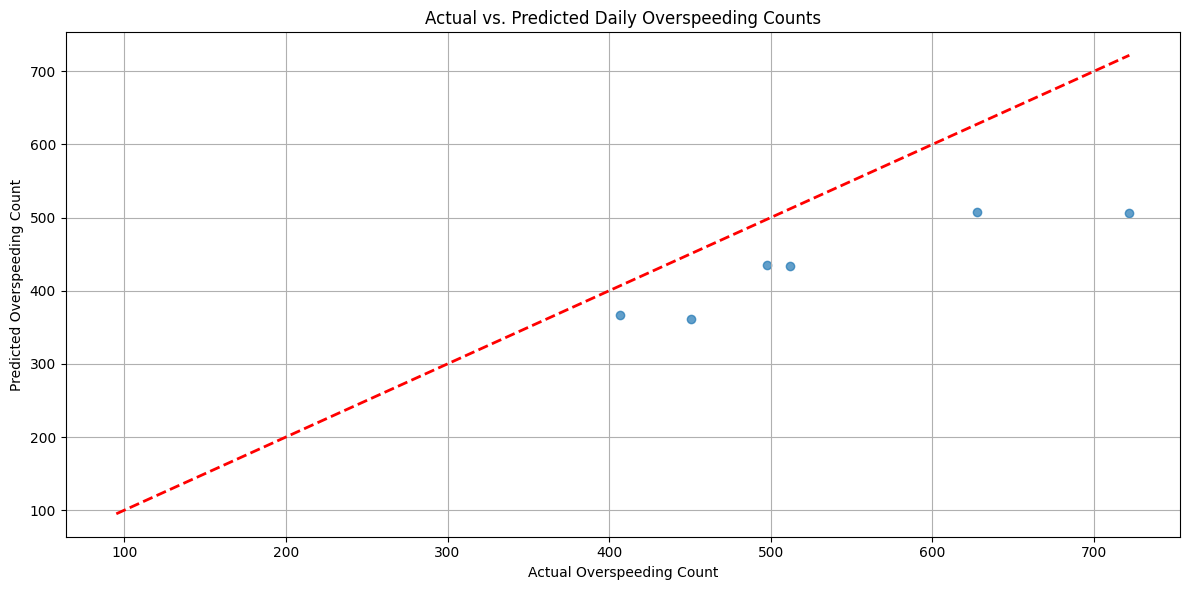


Machine Learning model training and evaluation complete.


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure daily_overspeeding is a DataFrame and datetime column is processed
if 'date_only' in daily_overspeeding.columns:
    daily_overspeeding['date_only'] = pd.to_datetime(daily_overspeeding['date_only'])

# Feature Engineering
# Extract features from date_only column
df_ml = daily_overspeeding.copy()
df_ml['day_of_week'] = df_ml['date_only'].dt.dayofweek  # Monday=0, Sunday=6
df_ml['day_of_month'] = df_ml['date_only'].dt.day
df_ml['month'] = df_ml['date_only'].dt.month

# Define features (X) and target (y)
X = df_ml[['day_of_week', 'day_of_month', 'month']]
y = df_ml['overspeeding_count']

# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("\n--- Model Evaluation ---")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R-squared (R2): {r2:.2f}")

# Visualize predictions vs actual values
plt.figure(figsize=(12, 6))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2) # Line for perfect prediction
plt.xlabel('Actual Overspeeding Count')
plt.ylabel('Predicted Overspeeding Count')
plt.title('Actual vs. Predicted Daily Overspeeding Counts')
plt.grid(True)
plt.tight_layout()
plt.show()

print("\nMachine Learning model training and evaluation complete.")

### Feature Importance with SHAP (SHapley Additive exPlanations)

We will use SHAP to explain the output of our Linear Regression model. SHAP values help us understand the impact of each feature on the model's prediction for each instance, providing local interpretability. The summary plot will show the overall feature importance.

In [ ]:
pip install shap

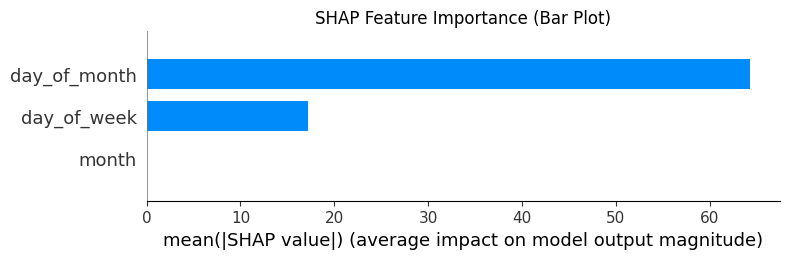

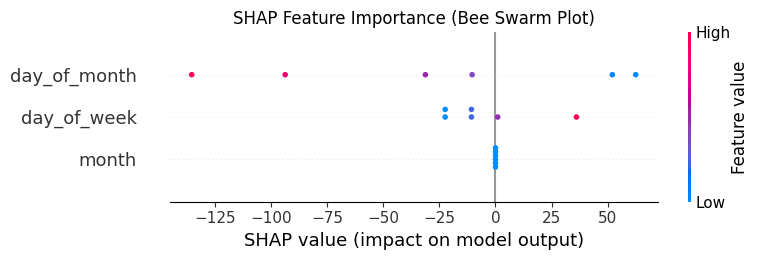

SHAP analysis complete. The plots above show the importance and impact of each feature on the model's predictions.


In [ ]:
import shap

# Create a SHAP explainer for the Linear Regression model
explainer = shap.Explainer(model, X_train)

# Calculate SHAP values for the test set
shap_values = explainer(X_test)

# Plot the SHAP summary plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Bar Plot)')
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Feature Importance (Bee Swarm Plot)')
plt.tight_layout()
plt.show()

print("SHAP analysis complete. The plots above show the importance and impact of each feature on the model's predictions.")

### Time-wise (Hourly) Overspeeding Trends (Removed as per user instruction)